[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/03_real_world_io/13_sql_fundamentals.ipynb)

# 📓 Notebook 13 — SQL Fundamentals with pandas

> **Module:** Data Engineering · **Estimated time:** 50–70 min · **Difficulty:** Beginner / Intermediate

Every analyst job description asks for **SQL**. Every modern data product uses it. And yet you can read 90% of the Python data-science internet without seeing a single `SELECT` statement.

This notebook closes that gap. We will load the AI-support-bot data into a tiny SQLite database (which ships with Python — no install), write SQL queries against it, do the same analyses in pandas, and learn when to reach for which. By the end you will be reading and writing SQL fluently against a database that lives entirely inside this notebook.

**One dataset runs through everything.** Picture you run customer support across five channels — Email, Chat, Phone, Web Form, Social — and an AI bot handles part of the load. Each month you record how many tickets came in, what fraction the bot automated, how fast it responded, how satisfied customers were, and what it cost. That table — `support_ops` — is the question machine for this whole notebook: *which channels does the bot serve well, and which need help?* Every clause we learn answers a sharper version of that question, and by the end we'll combine them into a one-page report a manager would actually read.

## 🎯 Learning objectives

By the end of this notebook you can:

1. Connect to a **SQLite** database from Python and create tables from a DataFrame.
2. Write the **six SQL clauses** that cover ~95% of analytics work: `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY`, `LIMIT`.
3. **Aggregate** with `COUNT`, `SUM`, `AVG`, `MIN`, `MAX`.
4. **Join** two tables on a key.
5. Use **CTEs** (`WITH ...`) to break a complex query into readable steps.
6. Move data between SQL and pandas with `read_sql` and `to_sql`.
7. Decide when SQL is the better tool than pandas (and vice versa).

## ✅ Prerequisites

Notebooks 1–12. No prior SQL needed. We use pandas (NB 7) to load query results into DataFrames.

> 🧭 **The mental model for the whole notebook.** *A SQL query is an assembly line.* You feed in a pile of rows and they pass down a conveyor belt of stations — keep these rows (`WHERE`), stack them into buckets (`GROUP BY`), drop some buckets (`HAVING`), pick what to show (`SELECT`), sort, trim. The twist that trips up every beginner: **the stations don't run in the order you write them.** You'll see the exact running order in §5, and once you do, half of SQL's confusing error messages explain themselves. Keep the conveyor belt in mind as we add one station at a time.

> 💡 **Why SQLite?** It is a serverless SQL database built into Python's standard library. No installation, no server. The exact same SQL you write here works (with a few syntactic differences) in PostgreSQL, MySQL, BigQuery, Snowflake, and every other SQL system you'll meet professionally.

## 1. SQL in one slide

Before touching the database, here's the whole language in one picture. SQL describes data manipulation as a sequence of **clauses** — the stations on our conveyor belt — that operate on tables:

```
SELECT   columns_or_aggregations         ← what you want
FROM     table                            ← where to look
WHERE    row_filter                       ← which rows
GROUP BY column(s)                        ← bucket rows together
HAVING   aggregate_filter                 ← which buckets
ORDER BY column(s)                        ← sort the result
LIMIT    n                                ← top-n only
```

You won't use every clause every time. A simple "show me the first ten rows" is just `SELECT * FROM table LIMIT 10` — two stations. A full quarterly report uses all of them.

The mental model: **SQL describes *what* you want, the database figures out *how*.** That declarative style is the source of both its power and its quirks — and it's why the conveyor belt runs in its *own* order, not yours (§5).

## 2. Setup — load a CSV into SQLite

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

# Build a fresh synthetic dataset inline (so the notebook is self-contained)
import numpy as np
RNG = np.random.default_rng(42)

channels = ["Email", "Chat", "Phone", "Web Form", "Social"]
months   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
profile = {
    "Email":    (0.55, 0.018, 4_200,  3_500, 4.10),
    "Chat":     (0.72, 0.012, 6_500,    900, 4.35),
    "Phone":    (0.18, 0.008, 2_100, 14_000, 3.85),
    "Web Form": (0.65, 0.015, 3_300,  6_000, 4.00),
    "Social":   (0.35, 0.030, 1_400,  2_400, 3.95),
}

**Now build the 60 monthly rows and load them into a DataFrame**

In [2]:
rows = []
for ch in channels:
    a0, g, vol, base_lat, base_sat = profile[ch]
    for i, m in enumerate(months):
        a = max(0.05, min(0.95, a0 + i * g + RNG.normal(0, 0.015)))
        v = int(vol * (1 + 0.01 * i + RNG.normal(0, 0.03)))
        lat = base_lat * (1 - 0.012 * i) * (1 + RNG.normal(0, 0.05))
        sat = max(1.0, min(5.0, base_sat + 0.4 * (a - a0)
              - 0.000_004 * (lat - base_lat) + RNG.normal(0, 0.05)))
        cost = max(0.15, a * 0.30 + (1 - a) * 5.50 + RNG.normal(0, 0.10))
        rows.append({"channel": ch, "month": m, "month_num": i+1,
                     "tickets_total": v, "tickets_auto": int(v*a),
                     "automation_rate": round(a, 3),
                     "latency_ms": int(lat), "satisfaction": round(sat, 2),
                     "cost_per_ticket": round(cost, 2)})
support_ops = pd.DataFrame(rows)

**Create an in-memory SQLite DB and load the DataFrame into a table**

In [3]:
# Create an in-memory SQLite database (no file on disk — instant)
conn = sqlite3.connect(":memory:")

# Push the DataFrame into a table
support_ops.to_sql("support_ops", conn, index=False, if_exists="replace")

print(f"✅ Loaded {len(support_ops)} rows into table 'support_ops'")
print(f"   Columns: {list(support_ops.columns)}")

✅ Loaded 60 rows into table 'support_ops'
   Columns: ['channel', 'month', 'month_num', 'tickets_total', 'tickets_auto', 'automation_rate', 'latency_ms', 'satisfaction', 'cost_per_ticket']


**What just happened.**

- `sqlite3.connect(":memory:")` opens a database that exists only in RAM — perfect for teaching.
- `df.to_sql("name", conn)` is the pandas → SQL bridge. Reverses with `pd.read_sql(...)`, shown next.

> 💡 **In real life** you'd use `sqlite3.connect("ops.db")` to persist the database to a file, or `sqlalchemy.create_engine("postgresql://...")` for a real production database. The rest of this notebook is identical regardless.

## 3. Your first SELECT

The data is loaded — now let's actually *ask it something*. The smallest possible question is "what's in here?", and the first two stations on the belt answer it: `SELECT` (what columns) and `FROM` (which table).

The `pd.read_sql(query, conn)` function runs a SQL query and gives you the result as a DataFrame. Let's use it to peek at the `support_ops` table.

In [4]:
# The simplest possible query — "give me the first 5 rows"
q = "SELECT * FROM support_ops LIMIT 5"
pd.read_sql(q, conn)


,channel,month,month_num,tickets_total,tickets_auto,automation_rate,latency_ms,satisfaction,cost_per_ticket
0,Email,Jan,1,4068,2255,0.555,3631,4.15,2.42
1,Email,Feb,2,4258,2335,0.548,3403,4.10,2.56
2,Email,Mar,3,4382,2625,0.599,3427,4.18,2.43
3,Email,Apr,4,4372,2584,0.591,3212,4.16,2.42
4,Email,May,5,4282,2651,0.619,3535,4.12,2.24


In [5]:
# Just the columns we care about
q = '''
SELECT channel, month, automation_rate, satisfaction
FROM support_ops
LIMIT 5
'''
pd.read_sql(q, conn)


,channel,month,automation_rate,satisfaction
0,Email,Jan,0.555,4.15
1,Email,Feb,0.548,4.10
2,Email,Mar,0.599,4.18
3,Email,Apr,0.591,4.16
4,Email,May,0.619,4.12


**Conventions worth picking up immediately:**

- **Uppercase keywords** (`SELECT`, `FROM`, `WHERE`) and **lowercase identifiers** (`channel`, `support_ops`). The DB doesn't care, but humans read SQL faster when it follows this convention.
- **One clause per line** for anything longer than a one-liner. Vertical SQL is much easier to debug.

## 4. WHERE — filtering rows

`SELECT *` dumps all 60 rows, but you rarely want *all* of them — you want the months that matter. *Which months was the bot genuinely crushing it?* That's a row filter, the next station on the belt.

`WHERE` is SQL's row filter — same job as a pandas boolean mask. It keeps only the rows that make its condition true, and (this matters later) it runs **early**, on raw rows, before anything is grouped.

In [6]:
# All months where the bot was working very well (high automation, high satisfaction)
q = '''
SELECT channel, month, automation_rate, satisfaction
FROM   support_ops
WHERE  automation_rate >= 0.80
   AND satisfaction    >= 4.30
ORDER BY automation_rate DESC
'''
pd.read_sql(q, conn)


,channel,month,automation_rate,satisfaction
0,Chat,Nov,0.847,4.33
1,Chat,Dec,0.844,4.48
2,Chat,Oct,0.825,4.43
3,Chat,Sep,0.810,4.42
4,Chat,Jul,0.802,4.38


In [7]:
# String comparisons — note the single quotes around the literal
q = '''
SELECT channel, month, latency_ms
FROM   support_ops
WHERE  channel = 'Phone'
   AND latency_ms > 10000
ORDER BY latency_ms DESC
LIMIT 5
'''
pd.read_sql(q, conn)


,channel,month,latency_ms
0,Phone,Jan,14153
1,Phone,Mar,14097
2,Phone,Apr,14061
3,Phone,Sep,14002
4,Phone,Aug,13454


**SQL operators that show up daily:**

| Operator | Meaning | Example |
|---|---|---|
| `=`, `<>`, `<`, `>`, `<=`, `>=` | comparisons | `WHERE channel = 'Chat'` |
| `AND`, `OR`, `NOT` | combine conditions | `WHERE a > 5 AND b < 10` |
| `IN (...)` | match any of a list | `WHERE channel IN ('Email','Chat')` |
| `BETWEEN x AND y` | range | `WHERE month_num BETWEEN 4 AND 6` |
| `LIKE 'pat%'` | string pattern (`%` = wildcard) | `WHERE channel LIKE 'E%'` |
| `IS NULL` / `IS NOT NULL` | missing values | `WHERE satisfaction IS NOT NULL` |

> ⚠️ **Use `IS NULL`, not `= NULL`.** SQL's three-valued logic (`TRUE` / `FALSE` / `UNKNOWN`) treats `column = NULL` as always *unknown*, so it never matches anything.

---

### ✋ Quick exercise (~2 min) — Filter the slow Chat months

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

The support team wants to investigate underperforming **Chat** months. Write a query that returns `channel`, `month`, and `automation_rate` for **Chat** rows where `automation_rate < 0.70`, sorted so the *lowest* automation rate comes first.

```python
# table: support_ops  (columns include channel, month, automation_rate)
```

In [8]:
# ✍️ Your turn 👇
# Fill in the ... below, then uncomment the last line to run it.
q = '''
SELECT ...
FROM   support_ops
WHERE  ...
ORDER BY ...
'''
# pd.read_sql(q, conn)


<details>
<summary>✅ <b>Solution</b></summary>

```python
q = '''
SELECT channel, month, automation_rate
FROM   support_ops
WHERE  channel = 'Chat'
   AND automation_rate < 0.70
ORDER BY automation_rate ASC
'''
pd.read_sql(q, conn)
```

The string literal `'Chat'` needs single quotes, and `ASC` (the default) puts the worst month on top so it's easy to spot.
</details>

## 5. Aggregations — the part that earns its keep

Filtering shows you individual rows, but the business question is rarely "show me row 37." It's *"how is each **channel** doing overall?"* — and that means collapsing 60 monthly rows into one summary per channel. That collapse is aggregation, and it's where SQL starts to feel like magic.

The five core aggregation functions — `COUNT`, `SUM`, `AVG`, `MIN`, `MAX` — combined with `GROUP BY` produce most of the analytical output a business consumes. `GROUP BY` is the "stack rows into buckets" station; the aggregate runs once *per bucket*.

In [9]:
# Total tickets and average automation rate, per channel
q = '''
SELECT channel,
       COUNT(*)               AS n_months,
       SUM(tickets_total)     AS total_tickets,
       AVG(automation_rate)   AS mean_auto_rate,
       AVG(satisfaction)      AS mean_satisfaction
FROM     support_ops
GROUP BY channel
ORDER BY total_tickets DESC
'''
pd.read_sql(q, conn).round(3)


,channel,n_months,total_tickets,mean_auto_rate,mean_satisfaction
0,Chat,12,81508,0.784,4.395
1,Email,12,53335,0.652,4.148
2,Web Form,12,41839,0.737,4.029
3,Phone,12,26600,0.221,3.872
4,Social,12,17634,0.513,4.011


### A `GROUP BY` result is a bar chart waiting to happen

The query above returned one row per channel. Feeding that straight into a bar chart is the natural last step of almost every aggregation.

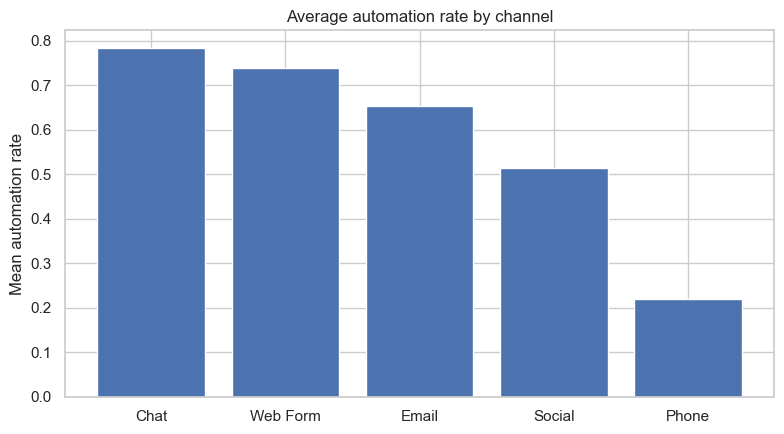

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
agg = pd.read_sql('''
    SELECT channel, AVG(automation_rate) AS mean_auto
    FROM   support_ops
    GROUP  BY channel
    ORDER  BY mean_auto DESC
''', conn)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(agg["channel"], agg["mean_auto"], color='#4C72B0')
ax.set_ylabel("Mean automation rate")
ax.set_title("Average automation rate by channel")
plt.tight_layout()
plt.show()


**How to read it:** bars are sorted best-to-worst, so the leftmost channel is the one your bot automates most effectively.

**Reading the query above:**

- `GROUP BY channel` buckets the 60 rows into 5 groups (one per channel).
- Each `AGG(...)` is computed *per bucket*.
- `AS column_name` renames the output — much clearer than the default `AVG(automation_rate)`.

> 🎯 **The rule of `GROUP BY`.** Every column in the `SELECT` list must either be in the `GROUP BY` clause **or** be wrapped in an aggregation function. Mixing the two without grouping is a beginner bug the database will (eventually) refuse to run.

### 🔬 What actually happens when a `SELECT` runs — the *logical* order

This is the conveyor belt from the intro, made precise — and here is the surprise that trips up almost every beginner: **SQL does not run in the order you write it.** You *write* `SELECT ... FROM ... WHERE ... GROUP BY ... HAVING ... ORDER BY ...`, but the engine *evaluates* the clauses in a completely different order. Knowing that order explains a dozen confusing error messages in one shot.

The engine processes one query like an assembly line. Each stage takes the rows from the previous stage, transforms them, and hands the result to the next stage:

```text
   YOU WRITE                       THE ENGINE RUNS  (top to bottom)
   ─────────                       ────────────────────────────────
   SELECT   ...                    ┌─────────────────┐
   FROM     ...        ╳           │ 1. FROM / JOIN  │  build the raw row set
   WHERE    ...        order       ├─────────────────┤
   GROUP BY ...        does        │ 2. WHERE        │  keep matching ROWS
   HAVING   ...        NOT         ├─────────────────┤
   ORDER BY ...        match       │ 3. GROUP BY     │  fold rows into groups
   LIMIT    ...                    ├─────────────────┤
                                   │ 4. HAVING       │  keep matching GROUPS
                                   ├─────────────────┤
                                   │ 5. SELECT       │  pick cols, make aliases
                                   ├─────────────────┤
                                   │ 6. ORDER BY     │  sort the result
                                   ├─────────────────┤
                                   │ 7. LIMIT        │  cut to first N rows
                                   └─────────────────┘
```

Two famous beginner bugs fall straight out of this picture:

| Confusion | Why it happens | The order explains it |
|---|---|---|
| "Why can't I use my `SELECT` alias in `WHERE`?" | `WHERE` runs at **step 2**, but the alias isn't created until `SELECT` at **step 5** | The alias doesn't exist yet at `WHERE`-time — Postgres, MySQL and most engines reject it. (SQLite is unusually lenient and *allows* it, but relying on that breaks the moment you move to another database.) |
| "What's the difference between `WHERE` and `HAVING`?" | `WHERE` (step 2) runs **before** grouping; `HAVING` (step 4) runs **after** | `WHERE` filters individual **rows**; `HAVING` filters whole **groups** |

> 🧠 **Mental model.** Read a query in *written* order, but *reason* about it in *execution* order: first you have a pile of rows (`FROM`), you throw some away (`WHERE`), you stack the survivors into buckets (`GROUP BY`), you throw away some buckets (`HAVING`), and only then do you choose what to show (`SELECT`) and how to sort it (`ORDER BY`).


In [11]:
# 🧪 PROOF — walk ONE query through every stage, printing the rows after each step.
# Self-contained: stdlib sqlite3 + an in-memory DB + tiny inline data. No pandas, no files.
import sqlite3

demo = sqlite3.connect(":memory:")          # a throwaway database that lives in RAM
demo.execute("""
    CREATE TABLE sales (
        channel TEXT,
        month   TEXT,
        tickets INTEGER
    )
""")
demo.executemany(
    "INSERT INTO sales (channel, month, tickets) VALUES (?, ?, ?)",
    [
        ("Email", "Jan", 120),
        ("Email", "Feb", 200),
        ("Chat",  "Jan",  50),   # Chat is small — it will get filtered/grouped out
        ("Phone", "Jan", 300),
        ("Phone", "Feb", 280),
    ],
)

**A little `show()` helper prints the rows after each stage**

In [12]:
def show(label, sql):
    rows = demo.execute(sql).fetchall()
    print(f"{label}")
    for r in rows:
        print("    ", r)
    print()

# The QUERY we are dissecting (written order):
#     SELECT   channel, SUM(tickets) AS total
#     FROM     sales
#     WHERE    tickets >= 100
#     GROUP BY channel
#     HAVING   SUM(tickets) > 250
#     ORDER BY total DESC
#     LIMIT    1

**Walk the query through FROM -> WHERE -> GROUP BY (steps 1-3)**

In [13]:
print("STEP 1 — FROM: the raw row set (everything, untouched)")
show("", "SELECT channel, month, tickets FROM sales")

print("STEP 2 — WHERE tickets >= 100: filter individual ROWS (Chat/Jan=50 is dropped)")
show("", "SELECT channel, month, tickets FROM sales WHERE tickets >= 100")

print("STEP 3 — GROUP BY channel: fold surviving rows into one bucket per channel")
show("(channel, SUM after grouping)",
     "SELECT channel, SUM(tickets) FROM sales WHERE tickets >= 100 GROUP BY channel")

STEP 1 — FROM: the raw row set (everything, untouched)

     ('Email', 'Jan', 120)
     ('Email', 'Feb', 200)
     ('Chat', 'Jan', 50)
     ('Phone', 'Jan', 300)
     ('Phone', 'Feb', 280)

STEP 2 — WHERE tickets >= 100: filter individual ROWS (Chat/Jan=50 is dropped)

     ('Email', 'Jan', 120)
     ('Email', 'Feb', 200)
     ('Phone', 'Jan', 300)
     ('Phone', 'Feb', 280)

STEP 3 — GROUP BY channel: fold surviving rows into one bucket per channel
(channel, SUM after grouping)
     ('Email', 320)
     ('Phone', 580)



**HAVING filters whole groups (step 4)**

In [14]:
print("STEP 4 — HAVING SUM(tickets) > 250: filter whole GROUPS — here both pass")
print("         (Email=320, Phone=580; change 250 to 400 and Email's group vanishes)")
show("(channel, SUM after HAVING)",
     "SELECT channel, SUM(tickets) FROM sales WHERE tickets >= 100 "
     "GROUP BY channel HAVING SUM(tickets) > 250")

STEP 4 — HAVING SUM(tickets) > 250: filter whole GROUPS — here both pass
         (Email=320, Phone=580; change 250 to 400 and Email's group vanishes)
(channel, SUM after HAVING)
     ('Email', 320)
     ('Phone', 580)



**SELECT alias, ORDER BY, then LIMIT (steps 5-7)**

In [15]:
print("STEP 5+6 — SELECT (make the 'total' alias) + ORDER BY total DESC: shape & sort")
show("(channel, total)",
     "SELECT channel, SUM(tickets) AS total FROM sales WHERE tickets >= 100 "
     "GROUP BY channel HAVING SUM(tickets) > 250 ORDER BY total DESC")

print("STEP 7 — LIMIT 1: keep only the first row of the sorted result")
show("(channel, total)",
     "SELECT channel, SUM(tickets) AS total FROM sales WHERE tickets >= 100 "
     "GROUP BY channel HAVING SUM(tickets) > 250 ORDER BY total DESC LIMIT 1")

STEP 5+6 — SELECT (make the 'total' alias) + ORDER BY total DESC: shape & sort
(channel, total)
     ('Phone', 580)
     ('Email', 320)

STEP 7 — LIMIT 1: keep only the first row of the sorted result
(channel, total)
     ('Phone', 580)



In [16]:
# ⚠️ PROOF that a SELECT alias is "born" at step 5 — AFTER WHERE (step 2) has already run.
import sqlite3
db = sqlite3.connect(":memory:")
db.execute("CREATE TABLE t (x INTEGER)")
db.executemany("INSERT INTO t VALUES (?)", [(1,), (5,), (9,)])

# Try to use the SELECT alias 'doubled' inside WHERE. By the logical order this is "too early":
# the alias is not defined until step 5, but WHERE is step 2.
try:
    rows = db.execute("SELECT x * 2 AS doubled FROM t WHERE doubled > 5").fetchall()
    print("⚠️  SQLite ALLOWED the alias in WHERE →", rows)
    print("    (Non-standard! Postgres/MySQL raise 'column \"doubled\" does not exist'.)")
except sqlite3.OperationalError as e:
    print("❌ Using the SELECT alias in WHERE fails:", e)

# The portable fix: repeat the expression — WHERE runs BEFORE the alias exists, so spell it out.
ok = db.execute("SELECT x * 2 AS doubled FROM t WHERE x * 2 > 5").fetchall()
print("✅ Repeat the expression in WHERE   →", ok)

# By contrast, ORDER BY runs at step 6 (AFTER SELECT), so it CAN see the alias everywhere:
ok2 = db.execute("SELECT x * 2 AS doubled FROM t ORDER BY doubled DESC").fetchall()
print("✅ ORDER BY can see the alias        →", ok2)


⚠️  SQLite ALLOWED the alias in WHERE → [(10,), (18,)]
    (Non-standard! Postgres/MySQL raise 'column "doubled" does not exist'.)
✅ Repeat the expression in WHERE   → [(10,), (18,)]
✅ ORDER BY can see the alias        → [(18,), (10,), (2,)]


### `HAVING` — filtering on aggregates

`WHERE` filters *rows*. `HAVING` filters *groups*. You usually want one or the other, sometimes both.

> 🚫 **Misconception — "`HAVING` and `WHERE` are interchangeable."**
> They run at *different stages*. `WHERE` filters **individual rows** *before* grouping; `HAVING` filters **whole groups** *after* `GROUP BY` has aggregated them. So `WHERE AVG(x) > 5` is an error (there are no groups yet), and putting a per-row condition in `HAVING` needlessly aggregates rows you could have dropped earlier. Rule of thumb: filter raw rows in `WHERE`, filter aggregates in `HAVING`.


In [17]:
# Channels with average automation rate > 60%
q = '''
SELECT channel,
       AVG(automation_rate) AS mean_auto
FROM     support_ops
GROUP BY channel
HAVING   AVG(automation_rate) > 0.60
ORDER BY mean_auto DESC
'''
pd.read_sql(q, conn).round(3)


,channel,mean_auto
0,Chat,0.784
1,Web Form,0.737
2,Email,0.652


### 🔮 Predict the output

`NULL` is not zero — and aggregates treat it in a way that surprises almost everyone. Predict the two printed numbers **before** running. A tiny in-memory table has 4 rows; one row's `amount` is `NULL`:

```python
import sqlite3
c = sqlite3.connect(":memory:")
c.execute("CREATE TABLE t (amount INTEGER)")
c.executemany("INSERT INTO t VALUES (?)", [(10,), (20,), (30,), (None,)])

# How many rows does COUNT see, and what does AVG divide by?
print(c.execute("SELECT COUNT(*), COUNT(amount) FROM t").fetchone())
print(c.execute("SELECT AVG(amount), SUM(amount)/COUNT(*) FROM t").fetchone())
```

What does each line print?


In [18]:
import sqlite3
c = sqlite3.connect(":memory:")
c.execute("CREATE TABLE t (amount INTEGER)")
c.executemany("INSERT INTO t VALUES (?)", [(10,), (20,), (30,), (None,)])

# How many rows does COUNT see, and what does AVG divide by?
print(c.execute("SELECT COUNT(*), COUNT(amount) FROM t").fetchone())
print(c.execute("SELECT AVG(amount), SUM(amount)/COUNT(*) FROM t").fetchone())


(4, 3)
(20.0, 15)


<details>
<summary>💡 <b>Answer</b></summary>

`(4, 3)` then `(20.0, 15)`.

- `COUNT(*)` counts **rows** → `4`. `COUNT(amount)` counts **non-NULL values** → `3`.
- `AVG(amount)` sums the non-NULLs (`60`) and divides by the **non-NULL count** (`3`) → `20.0`. It silently *ignores* the `NULL`.
- `SUM(amount)/COUNT(*)` is the trap: `SUM` ignores the `NULL` (`60`) but you divided by `COUNT(*) = 4`, giving `15`. Mixing `COUNT(*)` with a value-aggregate is how "averages" quietly come out wrong when NULLs are present.
</details>


---

### ✋ Quick exercise (~2 min) — Which channels keep customers happy?

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Leadership only cares about channels with strong customer satisfaction. For each `channel`, compute the **average satisfaction** (alias it `mean_sat`), keep only channels whose average is **above 4.0**, and sort highest-first.

```python
# table: support_ops  (one row per channel-month; has a satisfaction column)
```

In [19]:
# ✍️ Your turn 👇
# Fill in the ... below, then uncomment the last line to run it.
q = '''
SELECT channel, ... AS mean_sat
FROM     support_ops
GROUP BY ...
HAVING   ...
ORDER BY ...
'''
# pd.read_sql(q, conn).round(3)


<details>
<summary>✅ <b>Solution</b></summary>

```python
q = '''
SELECT channel,
       AVG(satisfaction) AS mean_sat
FROM     support_ops
GROUP BY channel
HAVING   AVG(satisfaction) > 4.0
ORDER BY mean_sat DESC
'''
pd.read_sql(q, conn).round(3)
```

`HAVING` filters *whole groups* after aggregation — you can't use `WHERE` here because the average doesn't exist until the rows are grouped.
</details>

## 6. Grouping by multiple columns and time

`GROUP BY` can take several columns — useful when you want a cross-tab.

In [20]:
# Quarterly automation rate per channel
q = '''
SELECT channel,
       CASE
         WHEN month_num <= 3 THEN 'Q1'
         WHEN month_num <= 6 THEN 'Q2'
         WHEN month_num <= 9 THEN 'Q3'
         ELSE 'Q4'
       END                          AS quarter,
       AVG(automation_rate)         AS mean_auto
FROM     support_ops
GROUP BY channel, quarter
ORDER BY channel, quarter
'''
pd.read_sql(q, conn).round(3)


,channel,quarter,mean_auto
0,Chat,Q1,0.721
1,Chat,Q2,0.776
2,Chat,Q3,0.798
3,Chat,Q4,0.839
4,Email,Q1,0.567
5,Email,Q2,0.615
6,Email,Q3,0.696
7,Email,Q4,0.729
8,Phone,Q1,0.183
9,Phone,Q2,0.207


> 💡 **`CASE WHEN ... THEN ... ELSE ... END`** is SQL's if-elif-else. It runs once per row and returns a value. We just used it to turn a continuous month number into a categorical quarter — feature engineering in pure SQL.

**Seeing it:** a line per channel turns that quarterly table into a trend — automation climbing across `Q1 → Q4` is obvious at a glance.

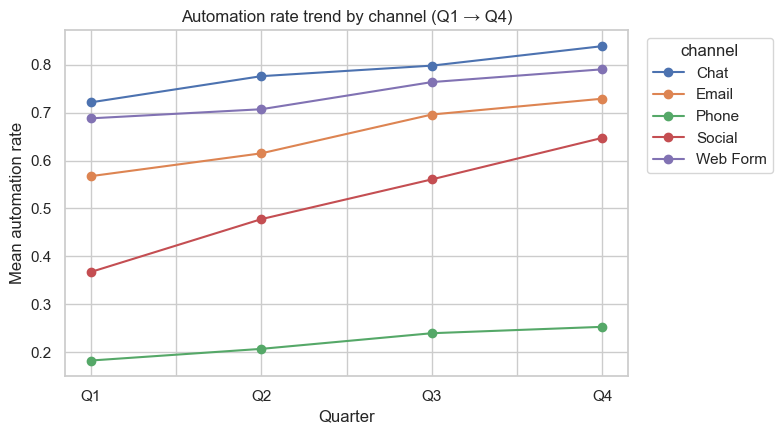

In [21]:
# Reuse the quarterly query (q, from just above) and pivot channels into columns
import matplotlib.pyplot as plt
quarterly = pd.read_sql(q, conn)
pivot = quarterly.pivot(index="quarter", columns="channel", values="mean_auto")

fig, ax = plt.subplots(figsize=(8, 4.5))
pivot.plot(marker="o", ax=ax)
ax.set_ylabel("Mean automation rate")
ax.set_xlabel("Quarter")
ax.set_title("Automation rate trend by channel (Q1 → Q4)")
ax.legend(title="channel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. JOINs — bringing two tables together

So far every answer came from the *one* `support_ops` table. But real questions cross tables: *"which **team lead** owns the worst-performing channel?"* That fact lives somewhere else — in a table about the channels themselves. To answer it you must **join**.

Real databases have many tables. Imagine we have a separate table of **channel metadata** — the team manager, the channel's launch year, and so on. Let's create one and join it back.

In [22]:
# A small "dimension" table about each channel
channel_meta = pd.DataFrame([
    {"channel": "Email",    "team_lead": "Anna",  "launched_year": 2018, "is_voice": 0},
    {"channel": "Chat",     "team_lead": "Bilal", "launched_year": 2020, "is_voice": 0},
    {"channel": "Phone",    "team_lead": "Carla", "launched_year": 2010, "is_voice": 1},
    {"channel": "Web Form", "team_lead": "Diego", "launched_year": 2019, "is_voice": 0},
    {"channel": "Social",   "team_lead": "Elena", "launched_year": 2023, "is_voice": 0},
])
channel_meta.to_sql("channel_meta", conn, index=False, if_exists="replace")

# Now join: each row of support_ops gets the team_lead and launched_year attached
q = '''
SELECT s.channel,
       s.month,
       s.automation_rate,
       m.team_lead,
       m.launched_year
FROM   support_ops AS s
JOIN   channel_meta AS m ON s.channel = m.channel
WHERE  s.month_num = 12         -- December only
ORDER BY s.automation_rate DESC
'''
pd.read_sql(q, conn).round(3)


,channel,month,automation_rate,team_lead,launched_year
0,Chat,Dec,0.844,Bilal,2020
1,Web Form,Dec,0.805,Diego,2019
2,Email,Dec,0.738,Anna,2018
3,Social,Dec,0.683,Elena,2023
4,Phone,Dec,0.271,Carla,2010


**The four kinds of JOIN, in plain English:**

| Type | Keeps … |
|---|---|
| `INNER JOIN` (default) | rows that match in **both** tables |
| `LEFT JOIN`            | every row from the left, with `NULL` where the right has no match |
| `RIGHT JOIN`           | the mirror image (rare in modern SQL — flip your tables) |
| `FULL OUTER JOIN`      | every row from either side; matches where possible |

> 🎯 **99% of the time you want `INNER JOIN` or `LEFT JOIN`.** Reach for `LEFT JOIN` whenever the right table might be missing rows for some keys and you don't want to drop those rows.

### 🔬 What actually happens when a `JOIN` matches rows

A `JOIN` is not magic — it is a **matchmaker**. For every row on the **left**, it scans the **right** table looking for rows where the join key is equal (`ON s.channel = m.channel`). What it does with the matches (and the *non*-matches) is the whole story:

```text
   LEFT TABLE (orders)          RIGHT TABLE (customers)
   ───────────────────          ───────────────────────
   id  cust_id  amount          cust_id  name
   ─── ───────  ──────          ───────  ────
   1   100      40   ───┐       100      Anna
   2   100      15   ───┼──────▶100  ───▶ (matches twice: rows 1 & 2)
   3   200      99   ───┼──────▶200  ───▶ Bilal
   4   999      10   ───┘   ✗   (no cust_id 999 on the right)
                              300      Carla   ◀── nobody on the left points here

   ON orders.cust_id = customers.cust_id
```

What each join *keeps* given that picture:

| Row | Matches? | `INNER JOIN` | `LEFT JOIN` |
|---|---|---|---|
| order 1 (cust 100) | ✅ → Anna | kept | kept |
| order 2 (cust 100) | ✅ → Anna | kept | kept |
| order 3 (cust 200) | ✅ → Bilal | kept | kept |
| order 4 (cust 999) | ❌ no match | **dropped** | **kept**, name = `NULL` |
| customer 300 (Carla) | only on right | dropped | dropped |

- **`INNER JOIN`** keeps only rows that match on **both** sides. Order 4 (no customer) and Carla (no order) both vanish.
- **`LEFT JOIN`** keeps **every left row**. Order 4 survives, but since there's no matching customer, its `name` comes back as `NULL`. (You'll see the same `NULL` again in the budgets `LEFT JOIN` just below.)

> 🧠 **Mental model.** Picture the left table as a checklist you must get through. `INNER JOIN` = "only keep checklist items that found a partner." `LEFT JOIN` = "keep every checklist item; leave a blank (`NULL`) where there was no partner."

> ⚠️ **One left row can become many output rows.** If a left row matches *three* right rows, you get *three* output rows. A join can therefore make your result set **larger** than the left table — a classic surprise when an unexpected duplicate key inflates your counts.


In [23]:
# 🧪 PROOF — INNER vs LEFT JOIN over two tiny tables. Stdlib sqlite3, in-memory, no pandas.
import sqlite3

j = sqlite3.connect(":memory:")
j.execute("CREATE TABLE orders    (id INTEGER, cust_id INTEGER, amount INTEGER)")
j.execute("CREATE TABLE customers (cust_id INTEGER, name TEXT)")

j.executemany("INSERT INTO orders VALUES (?, ?, ?)", [
    (1, 100, 40),
    (2, 100, 15),
    (3, 200, 99),
    (4, 999, 10),   # cust_id 999 has NO matching customer
])
j.executemany("INSERT INTO customers VALUES (?, ?)", [
    (100, "Anna"),
    (200, "Bilal"),
    (300, "Carla"),  # Carla has NO matching order
])

def run(title, sql):
    print(title)
    for row in j.execute(sql).fetchall():
        print("    ", row)
    print()

**INNER vs LEFT JOIN over the two tables**

In [24]:
run("INNER JOIN — only matched pairs survive (order 4 and Carla both disappear):", """
    SELECT o.id, o.cust_id, o.amount, c.name
    FROM   orders    AS o
    INNER JOIN customers AS c ON o.cust_id = c.cust_id
    ORDER BY o.id
""")

run("LEFT JOIN — every order is kept; order 4 has name = None (no customer 999):", """
    SELECT o.id, o.cust_id, o.amount, c.name
    FROM   orders   AS o
    LEFT JOIN customers AS c ON o.cust_id = c.cust_id
    ORDER BY o.id
""")

INNER JOIN — only matched pairs survive (order 4 and Carla both disappear):
     (1, 100, 40, 'Anna')
     (2, 100, 15, 'Anna')
     (3, 200, 99, 'Bilal')

LEFT JOIN — every order is kept; order 4 has name = None (no customer 999):
     (1, 100, 40, 'Anna')
     (2, 100, 15, 'Anna')
     (3, 200, 99, 'Bilal')
     (4, 999, 10, None)



**Count proof — one right row can match several left rows**

In [25]:
# Notice: Anna (cust 100) appears TWICE in the output — one right-table row
# matched by two left rows (orders 1 and 2).
matched = j.execute(
    "SELECT COUNT(*) FROM orders o JOIN customers c ON o.cust_id = c.cust_id"
).fetchone()[0]
print(f"INNER JOIN produced {matched} rows from 4 orders "
      f"(order 4 dropped → 3 survive; none multiplied here).")

INNER JOIN produced 3 rows from 4 orders (order 4 dropped → 3 survive; none multiplied here).


In [26]:
# A LEFT JOIN — useful when the right table might be missing entries
extra = pd.DataFrame([{"channel": "Email", "monthly_budget_usd": 12000}])
extra.to_sql("budgets", conn, index=False, if_exists="replace")

q = '''
SELECT s.channel,
       AVG(s.cost_per_ticket) AS mean_cost,
       b.monthly_budget_usd
FROM     support_ops AS s
LEFT JOIN budgets AS b ON s.channel = b.channel
GROUP BY s.channel
'''
pd.read_sql(q, conn).round(3)


,channel,mean_cost,monthly_budget_usd
0,Chat,1.377,NaN
1,Email,2.105,12000.0
2,Phone,4.347,NaN
3,Social,2.834,NaN
4,Web Form,1.633,NaN


See how channels without a budget show `None` instead of being dropped. That's the `LEFT JOIN` paying its way — you preserve all channels even when the budget table only knows about one.

---

### ✋ Quick exercise (~2 min) — Attach the team lead to each channel

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You want a one-line-per-channel report showing each channel's **average automation rate** next to **who runs it**. Join `support_ops` to `channel_meta`, group by channel, and return `channel`, `team_lead`, and `mean_auto` sorted best-first.

```python
# tables: support_ops (channel, automation_rate)  +  channel_meta (channel, team_lead, launched_year)
```

In [27]:
# ✍️ Your turn 👇
# Fill in the ... below, then uncomment the last line to run it.
q = '''
SELECT s.channel, m.team_lead, ... AS mean_auto
FROM     support_ops AS s
JOIN     channel_meta AS m ON ...
GROUP BY ...
ORDER BY ...
'''
# pd.read_sql(q, conn).round(3)


<details>
<summary>✅ <b>Solution</b></summary>

```python
q = '''
SELECT s.channel,
       m.team_lead,
       AVG(s.automation_rate) AS mean_auto
FROM     support_ops AS s
JOIN     channel_meta AS m ON s.channel = m.channel
GROUP BY s.channel, m.team_lead
ORDER BY mean_auto DESC
'''
pd.read_sql(q, conn).round(3)
```

The `JOIN ... ON s.channel = m.channel` glues each metrics row to its metadata, then `GROUP BY` collapses the twelve months per channel into one average.
</details>

## 8. CTEs — making complex queries readable

Watch what happens as questions get harder: filter, group, join, rank — pile those into one statement and you get a deeply nested query that nobody (including future-you) can read. There's a cleaner way to stack stations.

A **CTE** (Common Table Expression) lets you give a name to an intermediate query and reuse it. It is the SQL equivalent of breaking a long Python function into helper functions — each `WITH` block is one readable stage of the conveyor belt, written top to bottom.

In [28]:
# Without a CTE — works, but hard to read
q_inline = '''
SELECT channel, mean_auto, mean_sat
FROM (
  SELECT channel,
         AVG(automation_rate) AS mean_auto,
         AVG(satisfaction)    AS mean_sat
  FROM   support_ops
  GROUP BY channel
)
WHERE mean_auto > 0.5 AND mean_sat > 4.0
'''
print("Inline subquery result:")
print(pd.read_sql(q_inline, conn).round(3))

Inline subquery result:
    channel  mean_auto  mean_sat
0      Chat      0.784     4.395
1     Email      0.652     4.148
2    Social      0.513     4.011
3  Web Form      0.737     4.029


**The same query, rewritten with a CTE — read it top to bottom**

In [29]:
# Same query with a CTE — much easier to read and to extend
q_cte = '''
WITH channel_summary AS (
    SELECT channel,
           AVG(automation_rate) AS mean_auto,
           AVG(satisfaction)    AS mean_sat
    FROM   support_ops
    GROUP BY channel
)
SELECT *
FROM   channel_summary
WHERE  mean_auto > 0.5 AND mean_sat > 4.0
ORDER BY mean_auto DESC
'''
print("\nCTE result:")
print(pd.read_sql(q_cte, conn).round(3))



CTE result:
    channel  mean_auto  mean_sat
0      Chat      0.784     4.395
1  Web Form      0.737     4.029
2     Email      0.652     4.148
3    Social      0.513     4.011


> 💡 **When in doubt, CTE.** A 5-line CTE that you read top-to-bottom always beats a 5-level-deep nested subquery. Modern SQL style guides recommend CTEs for anything beyond a single `SELECT`.

## 9. SQL vs pandas — when to use which

You can do almost any analysis in either tool. So when do you reach for which?

| Use **SQL** when … | Use **pandas** when … |
|---|---|
| The data lives in a database — *don't move it before you have to*. | The data is already a DataFrame. |
| Joining 2–10 large tables on keys. | Reshaping a single dataset (pivot, melt, multi-index). |
| Filtering / aggregating "most" of a large table before bringing it into Python. | Doing per-row, per-column transformations that are awkward in SQL. |
| Sharing the query with non-Python colleagues. | Plugging into matplotlib, scikit-learn, etc. |
| The result needs to be a stable view that anyone can re-run. | Quick exploration, prototyping. |

> 🎯 **A common pro pattern:** *use SQL for the heavy lift, pandas for the last mile.* Pull a small filtered/aggregated table out of the database with SQL, then do the plotting / modelling in pandas. You get the best of both.

In [30]:
# Same analysis, two ways — pick the one that reads better
# A) Pure SQL
print("--- SQL ---")
print(pd.read_sql('''
    SELECT channel,
           AVG(automation_rate) AS mean_auto
    FROM   support_ops
    GROUP BY channel
    ORDER BY mean_auto DESC
''', conn).round(3))

# B) Pure pandas
print("\n--- pandas ---")
print(support_ops.groupby("channel")["automation_rate"]
                 .mean().sort_values(ascending=False)
                 .round(3).to_frame())


--- SQL ---
    channel  mean_auto
0      Chat      0.784
1  Web Form      0.737
2     Email      0.652
3    Social      0.513
4     Phone      0.221

--- pandas ---
          automation_rate
channel                  
Chat                0.784
Web Form            0.737
Email               0.652
Social              0.513
Phone               0.221


For this tiny query they look equally readable. For a 4-table join with three CTEs and a window function — SQL wins on clarity. For a chained `.assign(...).pivot(...).rolling(...).plot()` — pandas wins.

## 10. Tiny tour of window functions

`GROUP BY` collapses each channel's twelve months into a single summary row — but sometimes you want to *keep every row* and still know how it ranks *within its channel*: "was this Email's best month or its worst?" Plain aggregation can't do that; window functions can.

Window functions compute an aggregate **per row** using a "window" of nearby rows — running totals, ranks, lag/lead. They are SQL's secret weapon, and the reason senior analysts swear by them.

In [31]:
# Rank each channel's months from best to worst by automation rate
q = '''
SELECT channel,
       month,
       automation_rate,
       RANK() OVER (PARTITION BY channel ORDER BY automation_rate DESC) AS auto_rank
FROM support_ops
ORDER BY channel, auto_rank
'''
pd.read_sql(q, conn).head(15)


,channel,month,automation_rate,auto_rank
0,Chat,Nov,0.847,1
1,Chat,Dec,0.844,2
2,Chat,Oct,0.825,3
3,Chat,Sep,0.810,4
4,Chat,Jul,0.802,5
5,Chat,Jun,0.787,6
6,Chat,Aug,0.782,7
7,Chat,May,0.775,8
8,Chat,Apr,0.766,9
9,Chat,Feb,0.744,10


Within each channel the twelve months are ranked 1–12: `auto_rank = 1` is that channel's best month, `auto_rank = 2` the runner-up, and so on. That's a *ranking inside each group* — a pattern that costs you a `groupby + transform` dance in pandas but one line of SQL.

Window-function shapes worth knowing:

- `RANK() OVER (...)` — competition ranking (ties share a rank).
- `ROW_NUMBER() OVER (...)` — unique 1, 2, 3, … even for ties.
- `SUM(x) OVER (PARTITION BY g ORDER BY t)` — running total within each group.
- `LAG(x, 1) OVER (ORDER BY t)` — value from the previous row.

---

### ✋ Quick exercise (~2 min) — Rank months by satisfaction

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Reuse the window-function pattern you just saw, but rank by a different metric. **Within each channel**, rank the months by `satisfaction` so the happiest month is rank 1. Return `channel`, `month`, `satisfaction`, and the rank (`sat_rank`).

```python
# table: support_ops  (channel, month, satisfaction)
```

In [32]:
# ✍️ Your turn 👇
# Fill in the ... below, then uncomment the last line to run it.
q = '''
SELECT channel,
       month,
       satisfaction,
       RANK() OVER (PARTITION BY ... ORDER BY ...) AS sat_rank
FROM support_ops
ORDER BY channel, sat_rank
'''
# pd.read_sql(q, conn).head(15)


<details>
<summary>✅ <b>Solution</b></summary>

```python
q = '''
SELECT channel,
       month,
       satisfaction,
       RANK() OVER (PARTITION BY channel ORDER BY satisfaction DESC) AS sat_rank
FROM support_ops
ORDER BY channel, sat_rank
'''
pd.read_sql(q, conn).head(15)
```

`PARTITION BY channel` restarts the ranking for every channel, and `ORDER BY satisfaction DESC` makes the highest-satisfaction month rank 1.
</details>

## 11. Cleaning up

In [33]:
conn.close()
print("Connection closed.")


Connection closed.


## 🧪 Practice exercises

### Exercise 1 — ⭐ Recreate the connection and run a query

Reopen the connection, recreate the `support_ops` table from the DataFrame, then write a query that returns the **mean cost-per-ticket per channel**, sorted ascending.

In [34]:
# Your code here  👇
conn = sqlite3.connect(":memory:")
support_ops.to_sql("support_ops", conn, index=False, if_exists="replace")


60

<details>
<summary>💡 <b>Solution</b></summary>

```python
q = '''
SELECT channel,
       AVG(cost_per_ticket) AS mean_cost
FROM     support_ops
GROUP BY channel
ORDER BY mean_cost ASC
'''
pd.read_sql(q, conn).round(2)
```

Chat should come out cheapest, Phone most expensive. The pattern is **`SELECT … FROM … GROUP BY … ORDER BY`** — the four clauses you'll use in every other analytical query you write.
</details>

### Exercise 2 — ⭐⭐ A two-condition filter

Write a query that returns every (channel, month) where **automation_rate > 0.75 AND latency_ms < 2000**. Sort by automation_rate descending.

In [35]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
q = '''
SELECT channel, month, automation_rate, latency_ms
FROM   support_ops
WHERE  automation_rate > 0.75
   AND latency_ms      < 2000
ORDER BY automation_rate DESC
'''
pd.read_sql(q, conn).round(3)
```

These are the "fast + accurate" months — your *high-leverage* combinations of conditions.
</details>

### Exercise 3 — ⭐⭐ Best month per channel (window function)

Use a window function to find each channel's **single best month** (highest satisfaction). The result should have exactly 5 rows.

In [36]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
q = '''
WITH ranked AS (
    SELECT channel, month, satisfaction,
           ROW_NUMBER() OVER (PARTITION BY channel
                              ORDER BY satisfaction DESC) AS rn
    FROM support_ops
)
SELECT channel, month, satisfaction
FROM ranked
WHERE rn = 1
ORDER BY satisfaction DESC
'''
pd.read_sql(q, conn).round(2)
```

**Pattern.** Rank rows inside each group, then keep only `rn = 1`. This "top-N per group" pattern is a window-function classic — and the reason every senior analyst learns them.
</details>

### Exercise 4 — ⭐⭐ Join with the metadata table

Recreate `channel_meta` (as we did in §7), then write a query that returns the **mean automation rate** per channel together with its **team lead** and **launched year**, sorted by automation rate descending.

In [37]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
channel_meta = pd.DataFrame([
    {"channel": "Email",    "team_lead": "Anna",  "launched_year": 2018},
    {"channel": "Chat",     "team_lead": "Bilal", "launched_year": 2020},
    {"channel": "Phone",    "team_lead": "Carla", "launched_year": 2010},
    {"channel": "Web Form", "team_lead": "Diego", "launched_year": 2019},
    {"channel": "Social",   "team_lead": "Elena", "launched_year": 2023},
])
channel_meta.to_sql("channel_meta", conn, index=False, if_exists="replace")

q = '''
SELECT s.channel,
       AVG(s.automation_rate) AS mean_auto,
       m.team_lead,
       m.launched_year
FROM     support_ops AS s
JOIN     channel_meta AS m ON s.channel = m.channel
GROUP BY s.channel, m.team_lead, m.launched_year
ORDER BY mean_auto DESC
'''
pd.read_sql(q, conn).round(3)
```

**Pattern used.** Join → group → aggregate → sort. This is the shape of every "X by Y, enriched with Z" report your stakeholders will ever ask for.
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The query below is supposed to return channels with **more than 50K total tickets**, but it raises an error. Find the bug.

```sql
SELECT channel
FROM   support_ops
WHERE  SUM(tickets_total) > 50000
GROUP BY channel
```

In [38]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Your fixed query  👇


<details>
<summary>💡 <b>Solution</b></summary>

`WHERE` filters individual rows **before** aggregation, so it cannot reference an aggregate like `SUM(...)`. Filtering on aggregates is the job of `HAVING`, which runs **after** the group is formed.

```python
q = '''
SELECT channel,
       SUM(tickets_total) AS total
FROM   support_ops
GROUP BY channel
HAVING SUM(tickets_total) > 50000
ORDER BY total DESC
'''
pd.read_sql(q, conn)
```

**Remember the order of operations in SQL:** `FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY → LIMIT`. Knowing this order makes 90% of confusing errors instantly obvious.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Running cumulative totals

Using a window function, return — for each (channel, month_num) — the **running cumulative ticket count** within that channel. Sort by channel, then month_num.


<details>
<summary>💡 <b>Solution</b></summary>

```python
q = '''
SELECT channel,
       month_num,
       tickets_total,
       SUM(tickets_total) OVER (PARTITION BY channel ORDER BY month_num) AS cumulative_tickets
FROM   support_ops
ORDER BY channel, month_num
'''
pd.read_sql(q, conn).head(15)
```

**Pattern used.** `SUM(...) OVER (PARTITION BY g ORDER BY t)` is the
canonical running-total expression. It's the SQL analogue of
`df.groupby("channel")["tickets"].cumsum()` — *and* it's how every
financial report computes year-to-date numbers.

</details>

### Stretch exercise B — ⭐⭐⭐ Self-join to compute month-over-month deltas

Use a self-join (or `LAG()`) to return each (channel, month_num) with its **month-over-month change** in automation_rate. The first month of each channel should have `delta = NULL`.


<details>
<summary>💡 <b>Solution</b></summary>

```python
q = '''
SELECT channel,
       month_num,
       automation_rate,
       automation_rate - LAG(automation_rate) OVER (
           PARTITION BY channel ORDER BY month_num
       ) AS delta
FROM support_ops
ORDER BY channel, month_num
'''
pd.read_sql(q, conn).head(15)
```

**`LAG()` is one of the most useful window functions** — it gives
you the previous row's value within a partition. Same shape as
`series.diff(1)` in pandas. The first row per channel is `NULL`
because there's no prior month.

</details>

### Stretch exercise C — ⭐⭐⭐ Top-N per group

Using an in-memory SQLite DB with a `sales` table (columns: `region`, `product`, `revenue`), find the **top-2 products by revenue within each region**.

Hint: window functions. SQLite supports `ROW_NUMBER() OVER (PARTITION BY ... ORDER BY ...)`.

In [39]:
# Your code here  👇
import sqlite3
con = sqlite3.connect(":memory:")
con.executescript("""
CREATE TABLE sales (region TEXT, product TEXT, revenue REAL);
INSERT INTO sales VALUES
  ('EU', 'A', 120), ('EU', 'B', 90),  ('EU', 'C', 150), ('EU', 'D',  60),
  ('US', 'A', 200), ('US', 'B', 180), ('US', 'C', 100), ('US', 'D', 220);
""")

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import sqlite3
con = sqlite3.connect(":memory:")
con.executescript("""
CREATE TABLE sales (region TEXT, product TEXT, revenue REAL);
INSERT INTO sales VALUES
  ('EU', 'A', 120), ('EU', 'B', 90),  ('EU', 'C', 150), ('EU', 'D',  60),
  ('US', 'A', 200), ('US', 'B', 180), ('US', 'C', 100), ('US', 'D', 220);
""")

sql = """
WITH ranked AS (
    SELECT region, product, revenue,
           ROW_NUMBER() OVER (PARTITION BY region ORDER BY revenue DESC) AS rk
    FROM   sales
)
SELECT region, product, revenue FROM ranked WHERE rk <= 2 ORDER BY region, rk;
"""
for row in con.execute(sql):
    print(row)
```

**Reasoning.** Top-N-per-group is the canonical use case for window functions. `ROW_NUMBER() OVER (PARTITION BY region ORDER BY revenue DESC)` numbers rows within each region starting at 1 from the highest revenue. We wrap the query in a CTE (`WITH ranked AS …`) so we can then filter by `rk <= 2` — you can't refer to a window-function alias in the same SELECT's `WHERE`, which is why the CTE is needed. If you ever need to allow ties, swap `ROW_NUMBER()` for `RANK()` (ties share a rank, gaps follow) or `DENSE_RANK()` (no gaps).
</details>

### Stretch exercise D — ⭐⭐⭐ Add a column and back-fill

You have a `users` table with `id` and `email`. Add a new column `email_domain` and back-fill it with everything after the `@` in each existing email. Then add a constraint that future inserts without an `email_domain` are rejected.

Hint: in SQLite you use `ALTER TABLE … ADD COLUMN`, then a single `UPDATE … SET … = SUBSTR(...)`.

In [40]:
# Your code here  👇
import sqlite3
con = sqlite3.connect(":memory:")
con.executescript("""
CREATE TABLE users (id INTEGER PRIMARY KEY, email TEXT);
INSERT INTO users VALUES
  (1, 'ada@example.com'),
  (2, 'linus@kernel.org'),
  (3, 'grace@navy.mil');
""")

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import sqlite3
con = sqlite3.connect(":memory:")
con.executescript("""
CREATE TABLE users (id INTEGER PRIMARY KEY, email TEXT);
INSERT INTO users VALUES
  (1, 'ada@example.com'),
  (2, 'linus@kernel.org'),
  (3, 'grace@navy.mil');
""")

# Step 1: add the new column (nullable by default in SQLite)
con.execute("ALTER TABLE users ADD COLUMN email_domain TEXT")

# Step 2: back-fill
con.execute("""
    UPDATE users
    SET    email_domain = SUBSTR(email, INSTR(email, '@') + 1)
""")

for row in con.execute("SELECT * FROM users"):
    print(row)

# Step 3: enforce non-null going forward (SQLite can't add a NOT NULL
# to an existing column directly — recreate the table or use a trigger).
con.execute("""
    CREATE TRIGGER users_domain_not_null
    BEFORE INSERT ON users
    FOR EACH ROW WHEN NEW.email_domain IS NULL
    BEGIN SELECT RAISE(ABORT, 'email_domain must be set'); END;
""")
```

**Reasoning.** This is the bread-and-butter of *schema migration*. Three notes. (1) `ADD COLUMN` is one of the few `ALTER TABLE` operations SQLite supports — most other RDBMS (Postgres, MySQL) are more flexible. (2) `SUBSTR(email, INSTR(email, '@') + 1)` is the SQLite way of writing `email.split('@')[1]`. (3) SQLite can't add `NOT NULL` to an existing column without rewriting the table; a `BEFORE INSERT` trigger gives you the same end-user effect with less surgery. In Postgres you'd use `ALTER TABLE … ALTER COLUMN … SET NOT NULL` after the back-fill.
</details>

## 🎁 Bonus mini-project — A SQL-driven mini report

Using only SQL (then convert the final result to a DataFrame), build a report with these columns: `channel`, `team_lead`, `total_tickets`, `mean_auto`, `mean_cost`. Sort by `total_tickets` descending. Use a `CTE` for the aggregation and a `JOIN` for the metadata.

In [41]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# A later section reset the in-memory DB, so re-register the lookup table on the current connection:
channel_meta.to_sql("channel_meta", conn, index=False, if_exists="replace")

q = '''
WITH agg AS (
    SELECT channel,
           SUM(tickets_total)   AS total_tickets,
           AVG(automation_rate) AS mean_auto,
           AVG(cost_per_ticket) AS mean_cost
    FROM   support_ops
    GROUP BY channel
)
SELECT a.channel,
       m.team_lead,
       a.total_tickets,
       a.mean_auto,
       a.mean_cost
FROM     agg AS a
JOIN     channel_meta AS m ON a.channel = m.channel
ORDER BY a.total_tickets DESC
'''
pd.read_sql(q, conn).round(3)
```

**What you built.** The same kind of one-page report a manager asks for at the end of every quarter — and the SQL is *legible*. A junior analyst could read it without asking what each step does. That readability is the real product of CTEs.
</details>

## 🧠 Key takeaways

We started with one table — `support_ops`, five channels, twelve months — and a single question: *which channels does the bot serve well?* Each clause was a station on the conveyor belt that sharpened the answer, until the bonus report combined them into something a manager would sign off on.

1. **SQL is declarative**: you describe *what* you want, the database figures out *how*.
2. The six core clauses — `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `ORDER BY`, `LIMIT` — cover most analytics work.
3. **The belt doesn't run in written order** (`FROM → WHERE → GROUP BY → HAVING → SELECT → ORDER BY → LIMIT`) — knowing this explains most confusing errors at a glance.
4. **`HAVING` filters aggregates; `WHERE` filters rows.** Different stations, different jobs.
5. **Every column in `SELECT` must be in `GROUP BY` or wrapped in an aggregation.**
6. **`INNER JOIN`** for "must match"; **`LEFT JOIN`** for "may be missing".
7. **CTEs (`WITH ... AS`)** make complex queries readable — use them freely.
8. **Window functions** let you compute aggregates per row — the secret weapon for top-N-per-group and running totals.
9. **SQL vs pandas:** SQL for joins and heavy aggregation; pandas for reshape, plot, model. They're complements, not rivals.

## ✅ Self-assessment

- [ ] Load a DataFrame into a SQLite table and read it back as a DataFrame
- [ ] Write a `SELECT ... WHERE ... ORDER BY ... LIMIT` query
- [ ] Aggregate with `GROUP BY` and the five basic aggregation functions
- [ ] Filter aggregates with `HAVING`
- [ ] Inner-join and left-join two tables
- [ ] Use a CTE (`WITH ...`) to structure a multi-step query
- [ ] Explain when SQL beats pandas and vice versa

## 🚀 Next step

Continue with **Notebook 14 — Scikit-Learn Basics** (`../04_machine_learning/14_sklearn_basics.ipynb`), where the data you can now load from anywhere — files, APIs, SQL — becomes training data for your first machine-learning models.